In [23]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from enum import Enum
from dataclasses import dataclass

In [27]:
class Direction(Enum):
    DIR_NONE = 0
    UP = 1
    RIGHT = 2
    DOWN = 3
    LEFT = 4
    

DIR_NONE = Direction.DIR_NONE
UP = Direction.UP
RIGHT = Direction.RIGHT
DOWN = Direction.DOWN
LEFT = Direction.LEFT


@dataclass
class TileData:
    direction: Direction
    can_take_belt: list[Direction]


In [133]:
class Tile(Enum):
    EMPTY = 0

    BELT_UP = 1
    BELT_RIGHT = 2
    BELT_DOWN = 3
    BELT_LEFT = 4

    BELT_RIGHT_UP = 5
    BELT_DOWN_RIGHT = 6
    BELT_LEFT_DOWN = 7
    BELT_UP_LEFT = 8

    BELT_UP_RIGHT = 9
    BELT_RIGHT_DOWN = 10
    BELT_DOWN_LEFT = 11
    BELT_LEFT_UP = 12

    # EMPTY = TileData(DIR_NONE, can_take_belt=[UP,RIGHT,DOWN,LEFT])
    # BELT_UP = TileData(UP, [DOWN])
    # BELT_RIGHT = TileData(RIGHT, [LEFT])
    # BELT_DOWN = TileData(DOWN, [UP])
    # BELT_LEFT = TileData(LEFT, [RIGHT])

    # BELT_RIGHT_UP = TileData(UP, [RIGHT])
    # BELT_DOWN_RIGHT = TileData(RIGHT, [DOWN])
    # BELT_LEFT_DOWN = TileData(DOWN, [LEFT])
    # BELT_UP_LEFT = TileData(LEFT, [UP])

    # BELT_UP_RIGHT = TileData(RIGHT, [UP])
    # BELT_RIGHT_DOWN = TileData(DOWN, [RIGHT])
    # BELT_DOWN_LEFT = TileData(LEFT, [DOWN])
    # BELT_LEFT_UP = TileData(UP, [LEFT])

    
    @classmethod
    def can_take_up(self) -> list:
        return [Tile.BELT_DOWN.value,
                Tile.BELT_UP_LEFT.value,
                Tile.BELT_UP_RIGHT.value]

    @classmethod
    def can_take_right(self) -> list:
        return [Tile.BELT_LEFT.value,
                Tile.BELT_RIGHT_DOWN.value,
                Tile.BELT_RIGHT_UP.value]

    @classmethod
    def can_take_down(self) -> list:
        return [Tile.BELT_UP.value,
                Tile.BELT_DOWN_LEFT.value,
                Tile.BELT_DOWN_RIGHT.value]

    @classmethod
    def can_take_left(self) -> list:
        return [Tile.BELT_RIGHT.value,
                Tile.BELT_LEFT_DOWN.value,
                Tile.BELT_LEFT_UP.value]
    
    




In [134]:
def plot_solve(solve):
    fig, ax = plt.subplots(1,solve.size(-1),figsize=(6*5, 6))
    for i, grid in enumerate(solve.permute(2,0,1)):
        ax[i].matshow(grid.detach().numpy(),vmin=0,vmax=1)
        ax[i].set
        ax[i].set_title(Tile(i))
    plt.show()

In [135]:
BOX_SIZE = 5
INPUT_POS = (2,0)

In [136]:
Tile.can_take_up()

[3, 8, 9]

In [139]:
def eval(solve,verbose=0):
    items = torch.zeros(BOX_SIZE,BOX_SIZE,len(Tile))
    items[INPUT_POS, :] = 1

    for i in range(10):
        mul = items * solve

        items = torch.zeros(BOX_SIZE,BOX_SIZE,len(Tile))
        for i in range(len(Tile)):
            if Tile(i) in [Tile.BELT_UP,Tile.BELT_LEFT_UP,Tile.BELT_RIGHT_UP]:
                items[0:-1, :, Tile.can_take_down()] += mul[1::,:,i].unsqueeze(-1).repeat(1,1,len(Tile.can_take_down()))
            if Tile(i) in [Tile.BELT_RIGHT,Tile.BELT_DOWN_RIGHT,Tile.BELT_UP_RIGHT]:
                items[:, 1::, Tile.can_take_left()] += mul[:,0:-1,i].unsqueeze(-1).repeat(1,1,len(Tile.can_take_left()))
            if Tile(i) in [Tile.BELT_DOWN,Tile.BELT_LEFT_DOWN,Tile.BELT_RIGHT_DOWN]:
                items[1::, :, Tile.can_take_up()] += mul[0:-1,:,i].unsqueeze(-1).repeat(1,1,len(Tile.can_take_up()))
            if Tile(i) in [Tile.BELT_LEFT,Tile.BELT_DOWN_LEFT,Tile.BELT_UP_LEFT]:
                items[:, 0:-1, Tile.can_take_right()] += mul[:,1::,i].unsqueeze(-1).repeat(1,1,len(Tile.can_take_right()))
        if verbose>=5:
            plt.matshow(items.detach().numpy().sum(-1))
            plt.show()
    if verbose>=1:
        plt.matshow(items.detach().numpy().sum(-1))
        plt.show()
        print(items.sum(),items[4,4].sum())
    # print(items.sum())
    return items

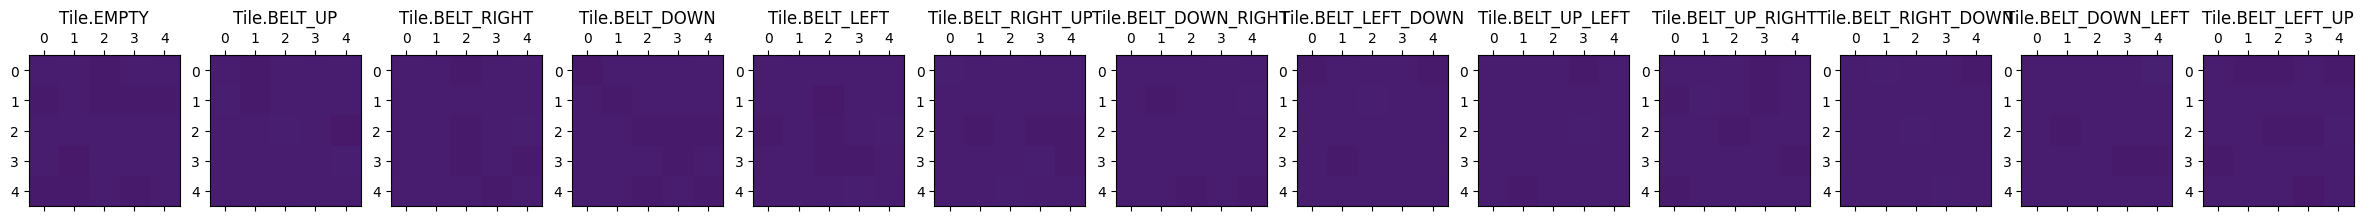

0.9999997615814209
0.9999997615814209
0.9999996423721313
0.9999996423721313
0.9999996423721313
0.9999996423721313
0.9999996423721313
0.9999996423721313
0.9999996423721313
0.9999996423721313
0.9999996423721313
0.9999996423721313
0.9999996423721313
0.9999995231628418
0.9999995231628418
0.9999995231628418
0.9999995231628418
0.9999995231628418
0.9999995231628418
0.9999995231628418
0.9999994039535522
0.9999994039535522
0.9999994039535522
0.9999994039535522
0.9999992847442627
0.9999991655349731
0.9999991655349731
0.9999991655349731
0.9999991655349731
0.9999990463256836
0.999998927116394
0.999998927116394
0.999998927116394
0.9999988079071045
0.9999988079071045
0.9999988079071045
0.9999985694885254
0.9999985694885254
0.9999985694885254
0.9999985694885254
0.9999983310699463
0.9999983310699463
0.9999982118606567
0.9999980926513672
0.9999980926513672
0.9999979734420776
0.9999978542327881
0.999997615814209
0.9999974966049194
0.9999973773956299
0.9999971389770508
0.9999970197677612
0.99999690055847

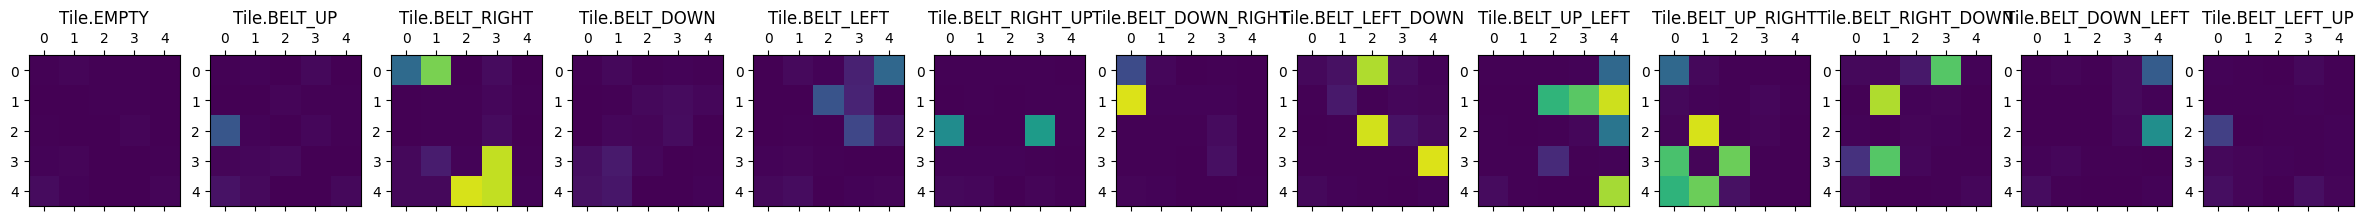

0.0013059850316494703
0.0009185898234136403
0.0012191550340503454
0.0016491491114720702
0.0020148647017776966
0.003759390441700816
0.0027297227643430233
0.0038734176196157932
0.004771354142576456
0.00517179723829031
0.003740323008969426
0.0032981466501951218
0.002994094043970108
0.0017864459659904242
0.0005415516789071262
0.0006196192116476595
0.0005134034436196089
0.004292283207178116
0.005938204471021891
0.004633394535630941
0.00702802836894989
0.009320668876171112
0.00945175252854824
0.009592622518539429
0.014820435084402561
0.017831427976489067
0.023417608812451363
0.026764189824461937
0.02740470878779888
0.02903677709400654
0.022870631888508797
0.02526336908340454
0.02694680728018284
0.023512253537774086
0.025522610172629356
0.02683512680232525
0.028410855680704117
0.03080553561449051
0.027085866779088974
0.026155954226851463
0.020349416881799698
0.024240437895059586
0.0274400245398283
0.025881195440888405
0.03239517658948898
0.0310562402009964
0.03324155882000923
0.04147242382168

In [140]:
logits = 0.01 * torch.randn(BOX_SIZE,BOX_SIZE,len(Tile))

logits.requires_grad_()
# solve = smax(solve)

MAX_ITER = 500

opt = torch.optim.Adam([logits], lr=0.1)
sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=100, T_mult=2)

for iter in range(MAX_ITER):
    with torch.no_grad():
        logits += 0.2 * torch.randn_like(logits)
    solve = torch.softmax(logits/5, dim=-1)

    if iter%250==0:
        plot_solve(solve)

    
    loss = (1-eval(solve)[4,4, :].sum())**2
    
    # loss += solve[:,:,1::].mean() * 0.01
    # loss += 3* ((1-solve.sum(dim=-1))**2).mean()
    print(loss.item())
    
    # if loss.item()<0.05:
    #     break

    loss.backward()
    opt.step()
    opt.zero_grad()
    sch.step()


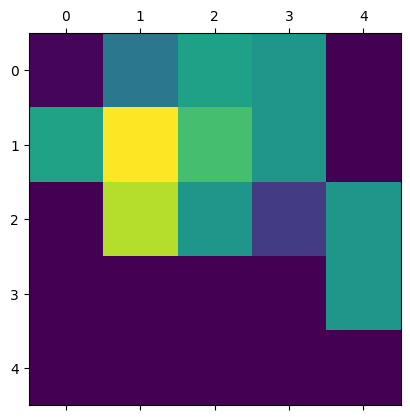

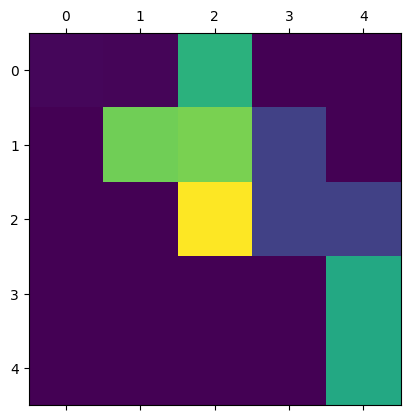

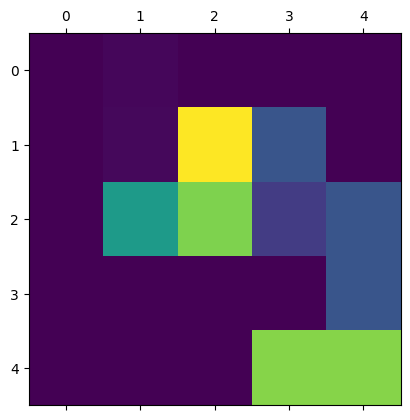

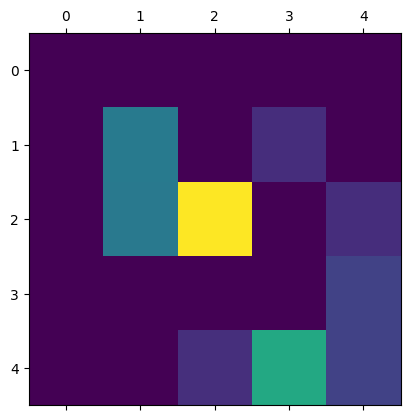

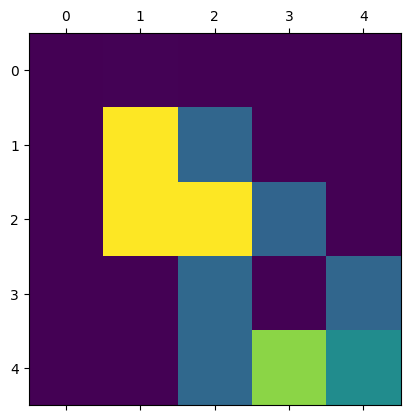

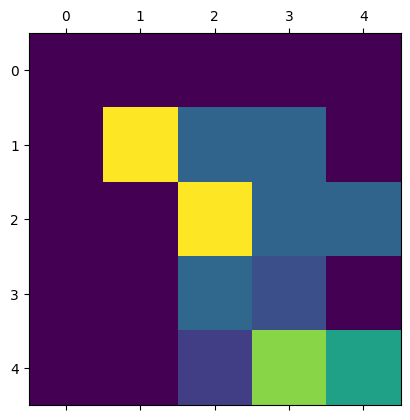

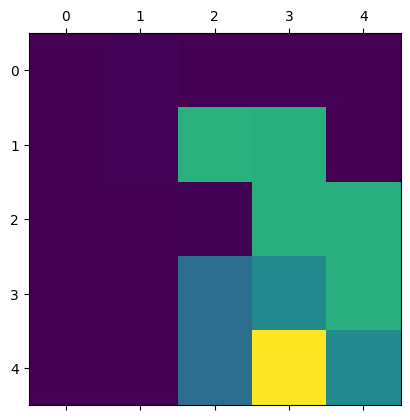

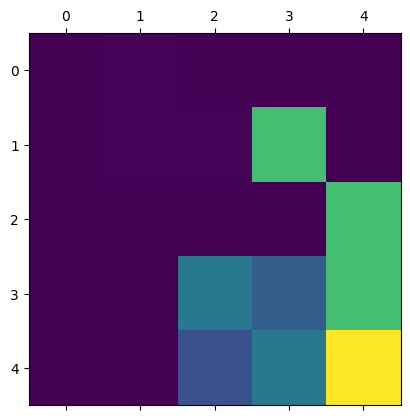

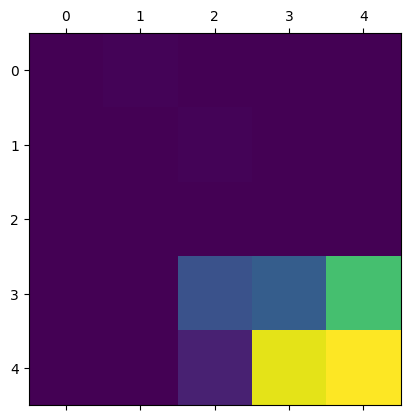

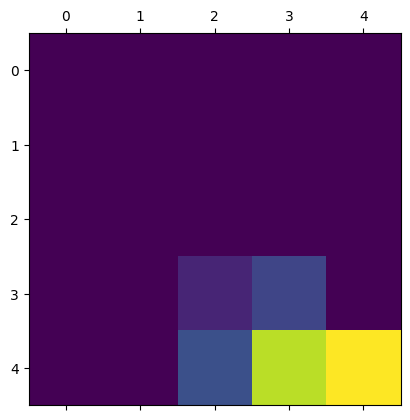

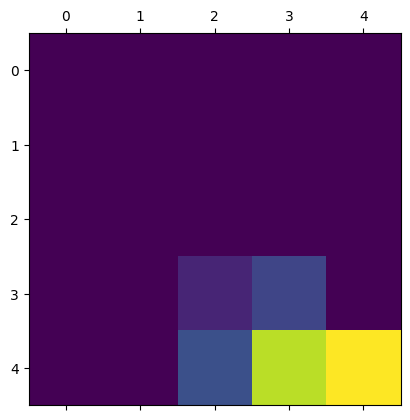

tensor(2.0012, grad_fn=<SumBackward0>) tensor(0.8164, grad_fn=<SumBackward0>)


tensor([[[0.0000e+00, 8.4391e-12, 0.0000e+00, 0.0000e+00, 2.6389e-08,
          2.6389e-08, 8.4391e-12, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          2.6389e-08, 8.4391e-12, 0.0000e+00],
         [0.0000e+00, 1.6569e-08, 0.0000e+00, 0.0000e+00, 2.0640e-08,
          2.3407e-19, 1.6569e-08, 2.0640e-08, 0.0000e+00, 0.0000e+00,
          2.3407e-19, 1.6569e-08, 2.0640e-08],
         [0.0000e+00, 2.4421e-08, 0.0000e+00, 0.0000e+00, 2.3432e-08,
          9.6042e-10, 2.4421e-08, 2.2472e-08, 0.0000e+00, 0.0000e+00,
          9.6042e-10, 2.4421e-08, 2.2472e-08],
         [0.0000e+00, 8.7889e-09, 0.0000e+00, 0.0000e+00, 4.6622e-13,
          4.6622e-13, 8.7889e-09, 1.1223e-18, 0.0000e+00, 0.0000e+00,
          4.6622e-13, 8.7889e-09, 1.1223e-18],
         [0.0000e+00, 5.4356e-09, 0.0000e+00, 0.0000e+00, 7.7194e-17,
          0.0000e+00, 5.4356e-09, 7.7194e-17, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 5.4356e-09, 7.7194e-17]],

        [[0.0000e+00, 2.5585e-18, 0.0000e+00, 3.4317e-11, 1.394

In [128]:
eval(solve,verbose=10)